# The Setup

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


Hehe! No missing values

In [4]:
y = df['target']
X = df.drop(columns=['target'])

# The Predictor

In [5]:
X = df[['age']]
y = df[['thalach']]

In [6]:
# split into train test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# train lin reg model
from sklearn.linear_model import LinearRegression 
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


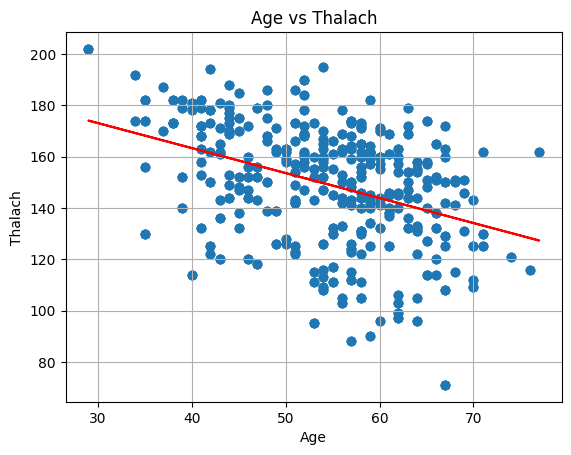

Thalach = Age * [[-0.97472057]] + [202.34392402]


In [8]:
# scatter plot of age vs thalach
import matplotlib.pyplot as plt 
plt.scatter(X, y)
plt.plot(X, lin_model.predict(X), color='red')
plt.xlabel('Age')
plt.ylabel('Thalach')
plt.title('Age vs Thalach')
plt.grid()
plt.show()
print(f'Thalach = Age * {lin_model.coef_} + {lin_model.intercept_}')

# The Classifier

In [9]:
X2 = df[['age', 'sex', 'cp', 'trestbps', 'chol']]
y2 = df[['target']]

In [10]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [29]:
# logistic regression
from sklearn.linear_model import LogisticRegression 
log_model = LogisticRegression()
log_model.fit(X_train2, y_train2.values.reshape(-1,))

y_pred = log_model.predict(X_test2)

### Just Visualising...

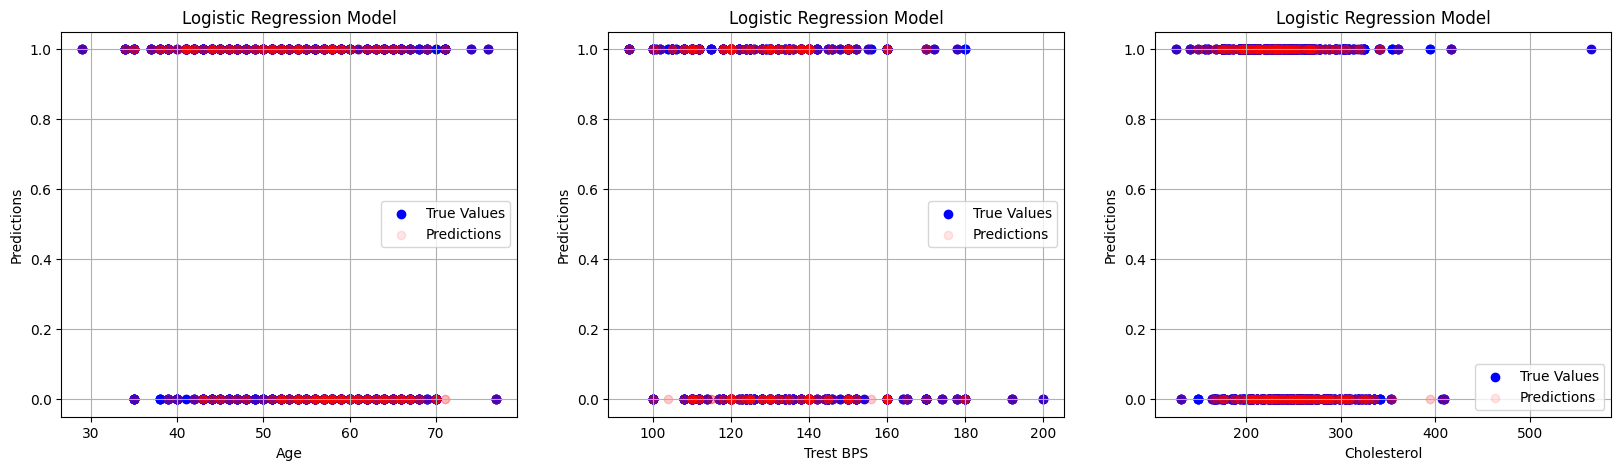

In [53]:
# plot the model
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

ax[0].scatter(X_train2['age'], y_train2, color='blue', label='True Values')
ax[0].scatter(X_train2['age'], log_model.predict(X_train2), color='red', label='Predictions', alpha=0.1)
ax[0].set_xlabel('Age')
ax[0].set_ylabel('Predictions')
ax[0].set_title('Logistic Regression Model')
ax[0].legend()
ax[0].grid()

ax[1].scatter(X_train2['trestbps'], y_train2, color='blue', label='True Values')
ax[1].scatter(X_train2['trestbps'], log_model.predict(X_train2), color='red', label='Predictions', alpha=0.1)
ax[1].set_xlabel('Trest BPS')
ax[1].set_ylabel('Predictions')
ax[1].set_title('Logistic Regression Model')
ax[1].legend()
ax[1].grid()

ax[2].scatter(X_train2['chol'], y_train2, color='blue', label='True Values')
ax[2].scatter(X_train2['chol'], log_model.predict(X_train2), color='red', label='Predictions', alpha=0.1)
ax[2].set_xlabel('Cholesterol')
ax[2].set_ylabel('Predictions')
ax[2].set_title('Logistic Regression Model')
ax[2].legend()
ax[2].grid()

plt.show()

# The Judge

In [13]:
# f1 score
from sklearn.metrics import f1_score 
f1 = f1_score(y_test2, y_pred)
print(f'F1 Score: {f1}')

F1 Score: 0.7902439024390244


F1 Score is the Harmonic Mean of Recall and Precision

F1 Score = (2 * Precision * Recall) / (Precision + Recall)

Precision is the ratio of number of instances that were actually positive and the model predicted them positive (True Positives) to the number of instances that were actually positive (True Positives + False Positives)

Precision = TP / (TP + FP)

Recall is the ratio of number of instances that were actually positive and the model predicted them positive (True Positives) to the number of instances that the model predicted positive (True Positives + False Negatives)

Recall = TP / (TP + FN)

In [14]:
# roc-auc score
from sklearn.metrics import roc_auc_score 
roc = roc_auc_score(y_test2, y_pred)
print(f'ROC-AUC Score: {roc}')

ROC-AUC Score: 0.7902627070245575


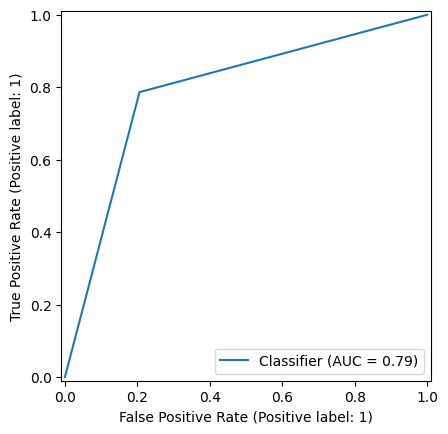

In [15]:
# plotting roc curve
from sklearn.metrics import RocCurveDisplay 
RocCurveDisplay.from_predictions(y_test2, y_pred)
plt.show()

# Bonus Challenge

In [16]:
X3 = df.drop(columns=['target'])
y3 = df['target']

In [17]:
X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y3, test_size=0.2, random_state=42)

In [18]:
# normalise / scaling data
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler() 

X_train3_scaled = scaler.fit_transform(X_train3)
X_test3_scaled = scaler.transform(X_test3)

In [19]:
log_model2 = LogisticRegression()
log_model2.fit(X_train3_scaled, y_train3)
y_pred3 = log_model2.predict(X_test3_scaled)

In [20]:
f1_2 = f1_score(y_test3, y_pred3)
print(f'F1 score: {f1_2}')

F1 score: 0.8108108108108109


ROC-AUC Score: 0.7947363411383972


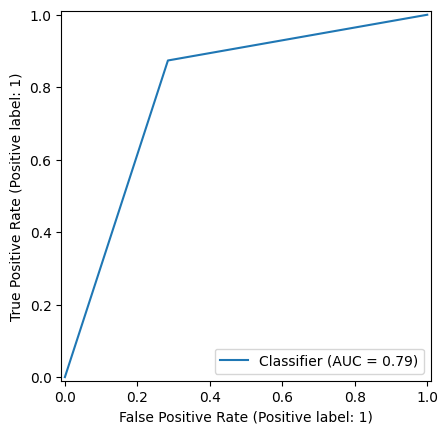

In [54]:
roc_2 = roc_auc_score(y_test3, y_pred3)
print(f'ROC-AUC Score: {roc_2}')
RocCurveDisplay.from_predictions(y_test3, y_pred3)
plt.show()

### ROC CURVE
A receiver operating characteristic (ROC), tells us about the performance of a binary classifier system as we change its discrimination threshold. It is created by plotting the ratio of true positives out of the positives (TPR = true positive rate) vs. the ratio of false positives out of the negatives (FPR = false positive rate), at various thresholds. TPR is also known as sensitivity, and FPR is one minus the specificity or true negative rate.